Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 172MB/s] 


Loading /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/REAL → 1500 files
Loading /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train/FAKE → 1500 files
Total features: (3000, 782)


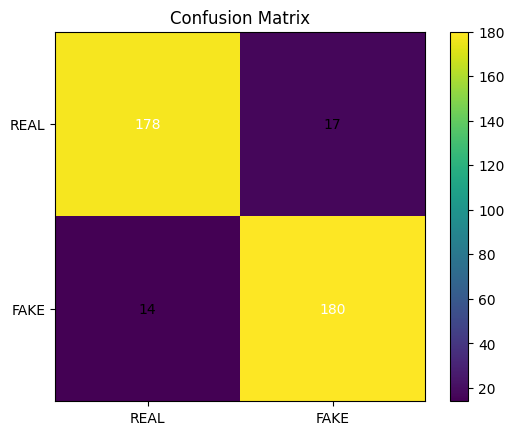

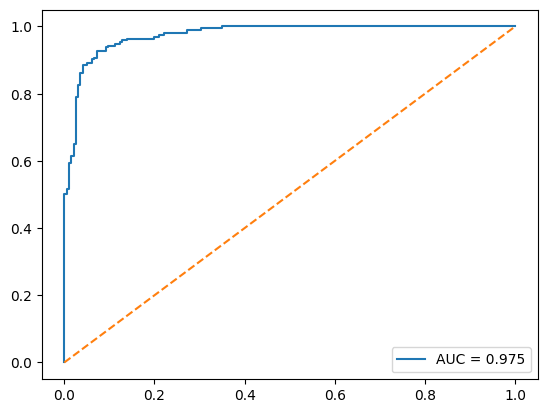


--- FINAL REPORT ---
Total Images: 400
REAL predicted: 192
FAKE predicted: 197
SUSPICIOUS: 11
Suspicious %: 2.75

Accuracy: 0.9203
AUC: 0.9749


In [1]:
import cv2
import os
import numpy as np
import torch
import torchvision.transforms as transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from scipy.fft import fft2, fftshift
import random
from sklearn.metrics import accuracy_score

# ---------------- SEED ----------------
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# ---------------- PATHS ----------------
train_path = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train"
test_path  = "/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test"

output_dir = "/kaggle/working/output"
os.makedirs(output_dir, exist_ok=True)

# ---------------- DEVICE ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- PATCH EXTRACTION ----------------
def extract_patches(img, patch_size=96, stride=48, max_patches=120):
    h, w, _ = img.shape

    if h < patch_size or w < patch_size:
        img = cv2.resize(img, (patch_size, patch_size))
        return [img]

    patches = []
    for y in range(0, h - patch_size, stride):
        for x in range(0, w - patch_size, stride):
            patches.append(img[y:y+patch_size, x:x+patch_size])

    if len(patches) == 0:
        patches.append(cv2.resize(img, (patch_size, patch_size)))

    patches = patches[:max_patches]
    return patches[:max_patches]

# ---------------- TRANSFORM ----------------
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


# ---------------- CNN ----------------

class CNNExtractor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.features = model.features
        self.pool = torch.nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        with torch.no_grad():
            x = self.features(x)
            x = self.pool(x)
        return x.view(x.size(0), -1)
cnn_model = CNNExtractor().to(device)

# ---------------- FEATURES ----------------
def glcm_features(gray):
    glcm = graycomatrix(gray, [1], [0], symmetric=True, normed=True)
    return [graycoprops(glcm, 'contrast')[0,0],
            graycoprops(glcm, 'energy')[0,0]]

def lbp_features(gray):
    lbp = local_binary_pattern(gray, 8, 1)
    hist, _ = np.histogram(lbp.ravel(), bins=10)
    return hist/(np.sum(hist)+1e-6)

def fft_features(gray):
    f = fft2(gray)
    fshift = fftshift(f)
    mag = np.log(np.abs(fshift)+1)
    return [np.mean(mag), np.std(mag)]

def extract_patch_feature(patch):
    gray = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

    ml = np.concatenate([
        glcm_features(gray),
        lbp_features(gray),
        fft_features(gray)
    ])

    img_t = transform(patch).unsqueeze(0).to(device)
    cnn = cnn_model(img_t).cpu().numpy()[0]
    ml = ml / (np.linalg.norm(ml) + 1e-6)
    cnn = cnn / (np.linalg.norm(cnn) + 1e-6)
    return np.hstack([ml, cnn])

# ---------------- LOAD DATA ----------------
def load_dataset(folder, label, max_images=1500):
    X, y = [], []
    files = os.listdir(folder)[:max_images]

    print(f"Loading {folder} → {len(files)} files")

    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        if img is None:
            continue

        patches = extract_patches(img)

        for p in patches:
            feat = extract_patch_feature(p)
            X.append(feat)
            y.append(label)

    return X, y

# ---------------- DATA ----------------
X_real, y_real = load_dataset(os.path.join(train_path, "REAL"), 0)
X_fake, y_fake = load_dataset(os.path.join(train_path, "FAKE"), 1)

X = np.array(X_real + X_fake)
y = np.array(y_real + y_fake)

print("Total features:", X.shape)

# ---------------- SCALER ----------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ---------------- SPLIT ----------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---------------- MODEL ----------------
model = XGBClassifier(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    n_jobs=-1
)

model.fit(X_train, y_train)

# ---------------- THRESHOLD ----------------
best_threshold = 0.18

# ---------------- PREDICT ----------------
def predict(img):
    patches = extract_patches(img)
    probs = []

    for p in patches:
        feat = extract_patch_feature(p)
        feat = scaler.transform([feat])
        prob = model.predict_proba(feat)[0]
        probs.append(prob)

    probs = np.array(probs)

    weights = np.max(probs, axis=1)**1.8
    avg_prob = np.average(probs, axis=0, weights=weights)

    diff = abs(avg_prob[0] - avg_prob[1])

    if diff < best_threshold*0.95:
        return "SUSPICIOUS", avg_prob

    return ("REAL" if np.argmax(avg_prob)==0 else "FAKE"), avg_prob

# ---------------- EVALUATION ----------------
def evaluate(real_path, fake_path):
    y_true, y_pred, y_prob = [], [], []

    real_c = fake_c = susp_c = 0

    for f in os.listdir(real_path)[:200]:
        img = cv2.imread(os.path.join(real_path, f))
        if img is None: continue

        pred, prob = predict(img)

        if pred == "SUSPICIOUS":
            susp_c += 1
            continue

        y_true.append(0)
        y_pred.append(0 if pred=="REAL" else 1)
        y_prob.append(prob[1])

        real_c += (pred == "REAL")
        fake_c += (pred == "FAKE")

    for f in os.listdir(fake_path)[:200]:
        img = cv2.imread(os.path.join(fake_path, f))
        if img is None: continue

        pred, prob = predict(img)

        if pred == "SUSPICIOUS":
            susp_c += 1
            continue

        y_true.append(1)
        y_pred.append(0 if pred=="REAL" else 1)
        y_prob.append(prob[1])

        real_c += (pred == "REAL")
        fake_c += (pred == "FAKE")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure()
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.xticks([0,1], ["REAL", "FAKE"])
    plt.yticks([0,1], ["REAL", "FAKE"])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max()/2 else "black"
            plt.text(j, i, cm[i, j], ha="center", va="center", color=color)

    plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
    plt.colorbar()
    plt.show()
    plt.close()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.savefig(os.path.join(output_dir, "roc_curve.png"))
    plt.show()
    plt.close()

    accuracy = accuracy_score(y_true, y_pred)

    total = real_c + fake_c + susp_c

    print("\n--- FINAL REPORT ---")
    print("Total Images:", total)
    print("REAL predicted:", real_c)
    print("FAKE predicted:", fake_c)
    print("SUSPICIOUS:", susp_c)
    print("Suspicious %:", round((susp_c/total)*100,2))

    print("\nAccuracy:", round(accuracy,4))
    print("AUC:", round(roc_auc,4))

# ---------------- RUN ----------------
evaluate(
    os.path.join(test_path, "REAL"),
    os.path.join(test_path, "FAKE")
)